In [1]:
from __future__ import division  # Python 2 compatibility
from scipy.special import binom
from scipy.interpolate import RectBivariateSpline
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import heapq
import math 
import pandas as pd

In [5]:
class TimeModel:
    """A class representing a model for calculating time-based paths."""

    def __init__(self, filename):
        """
        Initializes the TimeModel.

        Parameters:
        - start_lat_long (tuple): Tuple containing start latitude and longitude.
        - end_lat_long (tuple): Tuple containing end latitude and longitude.
        """
        # Read the bathymetry data from a file
        self.lines = self.readlines(filename)

        # Extract grid properties (ncols, nrows, etc.) from the read lines
        self.ncols = int(self.lines[0].split()[0])  # Extract the number of columns
        self.nrows = int(self.lines[1].split()[0])  # Extract the number of rows
        self.xllcorner = float(self.lines[2].split()[0])  # Extract x-coordinate of lower left corner
        self.yllcorner = float(self.lines[3].split()[0])  # Extract y-coordinate of lower left corner
        self.cellsize = float(self.lines[4].split()[0])  # Extract cell size
        # Create a matrix/grid using data starting from line 7
        self.grid = self.make_matrix(self.lines[6:])

        # Generate latitude and longitude grid used to pinpoint specific depths
        self.lat_long_grid = self.generate_lat_long_grid()

    def make_matrix(self, lines):
        # Converts the bathymetry data into a grid
        matrix = []
        for line in lines:
            line = line.split()
            new_line = [int(num) for num in line]
            matrix.append(new_line)
        return matrix

    def readlines(self, filename):
        # Reads in the bathymetry data
        with open(filename) as file:
            return file.readlines()

    def dijkstras_algorithm(self, start_lat_long, end_lat_long, width):
        """
        Implementation of Dijkstra's algorithm to find the shortest path.

        Returns:
        - lat_long_path (list): Shortest path in latitude and longitude coordinates.
        - total_time (float): Total time taken for the shortest path.
        """
        # Calculate the dimensions of the bathymetry grid
        rows = self.nrows
        cols = self.ncols
        
        start_point = self.find_start_point(self.shifted_start(start_lat_long, end_lat_long, width))
        end_point = self.find_start_point(end_lat_long)

        # Initialize distance and visited dictionaries
        # distance: Keeps track of the minimum distance to each node
        # visited: Keeps track of the previous node in the path
        distance = {start_point: 0}  # Start node has distance 0
        for row in range(rows):
            for col in range(cols):
                if self.grid[row][col] >= 0:
                    # Initialize all other nodes with infinite distance
                    distance[(row, col)] = float('inf')
        visited = {start_point: None}  # Start node has no previous node

        # Initialize the priority queue
        queue = [(0, start_point)]  # Heap queue sorted by shortest distance
        heapq.heapify(queue)

        while queue:
            # Get the node with the minimum distance from the queue
            current_time, current_node = heapq.heappop(queue)

            # Check if we have reached the end point
            if current_node == end_point:
                break

            # Explore the neighbors of the current node
            for neighbor in self.get_neighbors(current_node, rows, cols):
                if self.grid[neighbor[0]][neighbor[1]] >= 0:
                    continue # Skip obstacles or non-traversable nodes(nodes on land)

                # Calculate time required to move from current node to neighbor
                neighbor_depth = self.grid[neighbor[0]][neighbor[1]]
                current_depth = self.grid[current_node[0]][current_node[1]]
                time = (self.cellsize*111111) / (math.sqrt(((abs(current_depth) + abs(neighbor_depth)) / 2) * 9.8))

                # Calculate the new time for the neighbor through the current node
                new_time = distance[current_node] + time

                # Update if the new time to reach neighbor is shorter
                if neighbor not in distance or new_time < distance[neighbor]:
                    distance[neighbor] = new_time
                    visited[neighbor] = current_node  # Update previous node
                    heapq.heappush(queue, (new_time, neighbor))  # Push updated time and node to queue

        # Reconstruct the path from start to end
        path = []
        current = end_point
        while current:
            # path.append(current)
            # current = visited[current]
            try:
                path.append(current)
                current = visited[current]
            except (KeyError, TypeError) as e: # if an error gets thrown here,
                return None, -1                 # that means that the surrounding lat longs are all positive elevation


        path.reverse()  # Reverse to get the path from start to end
        lat_long_path = self.convert_path_to_lat_long(path)
        total_time = distance[end_point]  # Total time taken for the shortest path
        return lat_long_path, total_time/60

    def get_neighbors(self, node, rows, cols):
        """
        Retrieves neighboring nodes of a given node within the grid boundaries.

        Parameters:
        - node (tuple): Coordinates of the current node (row, col).
        - rows (int): Total rows in the grid.
        - cols (int): Total columns in the grid.

        Returns:
        - neighbors (list): List of neighboring nodes.
        """
        neighbors = []  # Initialize an empty list to store neighboring nodes
        row, col = node  # Unpack the current node's coordinates

        # Explore adjacent nodes and check grid boundaries
        # Append valid neighboring nodes to the 'neighbors' list
        if row > 0:
            neighbors.append((row - 1, col))  # Upper neighbor
        if row < rows - 1:
            neighbors.append((row + 1, col))  # Lower neighbor
        if col > 0:
            neighbors.append((row, col - 1))  # Left neighbor
        if col < cols - 1:
            neighbors.append((row, col + 1))  # Right neighbor

        return neighbors

    def generate_lat_long_grid(self):
        """
        Generates a grid of latitude and longitude coordinates.

        Returns:
        - grid (list): Grid of latitude and longitude coordinates.
        """
        start_value = (self.xllcorner, self.yllcorner)  # Starting latitude and longitude to line up with the bathymetry data
        increment = self.cellsize
        rows = self.nrows
        columns = self.ncols

        grid = []
        for row in range(rows):
            current_row = []
            for col in range(columns):
                value = (start_value[0] + col * increment, start_value[1] + row * increment)
                current_row.append(value)
            grid.append(current_row)

        return grid[::-1]  # Flipping the grid and returning it

    def find_start_point(self, lat_long_point):
        """
        Finds the closest grid point to a given latitude and longitude point.

        Parameters:
        - lat_long_point (tuple): Latitude and longitude coordinates.

        Returns:
        - closest_position (tuple): Closest grid point coordinates.
        """
        closest_value_diff = float('inf')  # Initialize a variable to track the closest value difference
        closest_position = (0,0) # Initialize a variable to store the closest position

        # Iterate through the grid to find the closest grid point
        for i in range(len(self.lat_long_grid)):
            for j in range(len(self.lat_long_grid[i])):
                current_tuple = self.lat_long_grid[i][j]  # Get current grid point coordinates

                # Calculate the absolute difference between the points
                value_diff = sum(abs(x - y) for x, y in zip(lat_long_point, current_tuple))

                # Check if the current grid point is closer than the previously closest one
                # and self.grid[closest_position[0]][closest_position[1]] < 0
                thing = self.grid[i][j]
                if value_diff < closest_value_diff and thing < 0:
                    #print("Close", thing)
                    closest_value_diff = value_diff  # Update the closest value difference
                    closest_position = (i, j)  # Update the closest position
        #thing = self.grid[closest_position[0]][closest_position[1]]
        return closest_position   # Return the coordinates of the closest grid point

    def convert_path_to_lat_long(self, path):
        """
        Converts a path of grid points to a list of latitude and longitude coordinates.

        Parameters:
        - path (list): List of grid points.

        Returns:
        - lat_long_path (list): List of latitude and longitude coordinates.
        """
        # Convert each grid point in the path to latitude and longitude coordinates
        lat_long_path = [self.lat_long_grid[row][col] for (row, col) in path]
        return lat_long_path
    
    def compute_derivative(self, h=None, fidelity=1):
        """
        Computes the derivative of the arrival time in the landslide model 
        with respect to latitude and longitude using a finite centered difference
        approximation.

        Parameters:
        - h (int): Step size for the finite difference approximation.

        Returns:
        - derivative (tuple): Tuple containing the derivative of the arrival time
        """

        file_path = r"C:\Users\ashle\Documents\Whitehead Research\Research 2023\1852\etopo.tt3"

        # Initialize the step size
        if type(h) != int or h is None:
            h = self.cellsize


        # Compute the derivative of the arrival time with respect to latitude
        lat_plus_h = (self.start_lat_long[0], self.start_lat_long[1] + h)
        lat_minus_h = (self.start_lat_long[0], self.start_lat_long[1] - h)
        derivative_lat_plus_instance = TimeModel(lat_plus_h, self.end_lat_long, file_path)
        path, arrival_time_plus_h = derivative_lat_plus_instance.dijkstras_algorithm()
        derivative_lat_minus_instance = TimeModel(lat_minus_h, self.end_lat_long, file_path)
        path, arrival_time_minus_h = derivative_lat_minus_instance.dijkstras_algorithm()
        dT_dlat = (arrival_time_plus_h - arrival_time_minus_h) / (2 * h)
        print(f"arrival_time_plus_h: {round(arrival_time_plus_h, 3)}")
        print(f"arrival_time_minus_h: {round(arrival_time_minus_h, 3)}")
        print(f"dT_dlat: {round(dT_dlat, 3)}")
        dT_dlat *= self.cellsize

        # Compute the derivative of the arrival time with respect to longitude
        long_plus_h = (self.start_lat_long[0] + h, self.start_lat_long[1])
        long_minus_h = (self.start_lat_long[0] - h, self.start_lat_long[1])
        derivative_long_plus_instance = TimeModel(long_plus_h, self.end_lat_long, file_path)
        path, arrival_time_plus_h = derivative_long_plus_instance.dijkstras_algorithm()
        derivative_long_minus_instance = TimeModel(long_minus_h, self.end_lat_long, file_path)
        path, arrival_time_minus_h = derivative_long_minus_instance.dijkstras_algorithm()
        dT_dlong = (arrival_time_plus_h - arrival_time_minus_h) / (2 * h)
        print(f"arrival_time_plus_h: {round(arrival_time_plus_h, 3)}")
        print(f"arrival_time_minus_h: {round(arrival_time_minus_h, 3)}")
        print(f"dT_dlong: {round(dT_dlong, 3)}")
        dT_dlong *= self.cellsize

        return [-dT_dlong, -dT_dlat]

    def shifted_start(self, start_lat_long, end_lat_long, width):
        deg_width = width / 111111  # width in meters approximated to degrees
        lon1, lat1 = start_lat_long
        lon2, lat2 = end_lat_long
        dist = math.sqrt((lon2 - lon1) ** 2 + (lat2 - lat1) ** 2) #distance formula
        unit_vector_x = (lon2 - lon1) / dist
        unit_vector_y = (lat2 - lat1) / dist

        x = lon1 + (deg_width/2) * unit_vector_x
        y = lat1 + (deg_width/2) * unit_vector_y

        return x, y

In [9]:
class TimeModelSimpsons:
    """A class to approximate line integrals using Simpson's rule
    based on Bezier curves to model arrival time of a tsunami.

    This class facilitates the calculation of speed functions
    derived from Bezier curves representing geographical path of the tsunami.
    It employs Simpson's rule for numerical integration to
    determine the speed along a path defined by control points.

    Attributes:
        control_points (numpy.ndarray): An array containing control points
            defining the Bezier curve's trajectory.
        matrix (numpy.ndarray): Matrix representation of bathymetry data.
        base_x (numpy.ndarray): Array representing the X-axis values.
        base_y (numpy.ndarray): Array representing the Y-axis values.
        cached_coefficients (dict): Cached binomial coefficients for optimization.

    Methods:
        __init__(self, control_points): Initializes the TimeModelSimpsons instance.
        get_depth(self, lon, lat): Retrieves depth values at given coordinates.
        binomial_coefficient(self, n, k): Computes binomial coefficients.
        bezier_curve(self, control_points, num_points=100): Calculates Bezier curves.
        derivative_bezier_curve(self, control_points, num_points=100): Computes the derivative of Bezier curves.
        get_derivative_at_t(self, control_points, t): Computes derivatives at a given point.
        speed_function(self, t): Computes the speed function at a given time.
        simpson(self, a, b, n, num_threads=24): Approximates definite integrals
            using Simpson's rule with multithreading support.
    """
    # Used to fetch cached values
    cached_coefficients = {}

    def __init__(self, control_points):
        """
        Initializes a TimeModelSimpsons instance.

        Args:
            control_points (numpy.ndarray): An array containing control points
                defining the Bezier curve's trajectory.
        Attributes:
            control_points (numpy.ndarray): An array containing control points defining the Bezier curve's trajectory.
            matrix (numpy.ndarray): Matrix representation of bathymetry data.
            base_x (numpy.ndarray): Array representing the X-axis values.
            base_y (numpy.ndarray): Array representing the Y-axis values.
            bezier_values (Tuple[numpy.ndarray, numpy.ndarray]): Tuple containing arrays
            representing the X and Y values of the Bezier curve.
            bezier_derivative_values (Tuple[numpy.ndarray, numpy.ndarray]): Tuple containing arrays
            representing the X and Y values of the derivative of the Bezier curve.
            cached_coefficients (dict): Cached binomial coefficients for optimization.
        """
        self.control_points = control_points
        self.matrix = np.array(getattr(time_model_instance, "grid")[::-1]).T
        self.base_x = [item[0] for item in getattr(time_model_instance, "lat_long_grid")[0]]
        self.base_y = [row[0][1] for row in getattr(time_model_instance, "lat_long_grid")][::-1]
        self.bezier_values = self.bezier_curve()
        self.bezier_derivative_values = self.derivative_bezier_curve()
    

   
    def get_depth(self, lon, lat):
        """
        Retrieves depth values at given coordinates (longitude and latitude).

        Args:
            lon (float): Longitude coordinate.
            lat (float): Latitude coordinate.

        Returns:
            float: Interpolated depth value at the specified coordinates.
        """

        # Extract the base X, Y, and Z values
        x = self.base_x
        y = self.base_y
        z = np.array(self.matrix)

        # Create an interpolation function using RectBivariateSpline from scipy
        interp_function = RectBivariateSpline(x, y, z)

        # Compute the interpolated depth value at the given coordinates
        interp_value = interp_function(lon, lat)

        return interp_value[0][0]

    def binomial_coefficient(self, n, k):
        """
        Computes binomial coefficients and caches results for optimization.

        Args:
            n (int): Total number of items.
            k (int): Number of items to choose.

        Returns:
            int: Binomial coefficient (n choose k).
        """

        # Check if the binomial coefficient for given n and k is already cached
        if (n, k) in self.cached_coefficients:
            return self.cached_coefficients[(n, k)]
        else:
            # Calculate the binomial coefficient using scipy's binom function
            res = binom(n, k)
            # Cache the computed binomial coefficient for future use
            self.cached_coefficients[(n, k)] = res
            return res

    def bezier_curve(self):
        """
        Calculates a Bezier curve based on control points.

        Args:
            control_points (numpy.ndarray): Array containing control points
                defining the Bezier curve's trajectory.
            num_points (int, optional): Number of points to generate on the curve.
                Defaults to 100.

        Returns:
            Tuple[numpy.ndarray, numpy.ndarray]: X and Y values of the Bezier curve.
        """

        # Determine the number of control points
        num_points = len(self.control_points) - 1

        # Generate an array of 't' values
        t_values = np.linspace(0, 1, num_points)

        # Initialize arrays to store X and Y values of the curve
        x_values = np.zeros(num_points, dtype=np.float64)
        y_values = np.zeros(num_points, dtype=np.float64)

        # Iterate through each 't' value
        for i in range(num_points + 1):
            # Calculate temporary values for X and Y components of the curve
            temp_x = (
                self.binomial_coefficient(num_points, i)
                * (1 - t_values) ** (num_points - i)
                * t_values**i
                * self.control_points[i, 0]
            )
            temp_y = (
                self.binomial_coefficient(num_points, i)
                * (1 - t_values) ** (num_points - i)
                * t_values**i
                * self.control_points[i, 1]
            )

            # Accumulate the temporary values to get the final curve
            x_values += temp_x
            y_values += temp_y
        return x_values, y_values

    def derivative_bezier_curve(self):
        """
        Calculates the derivative of a Bezier curve based on control points.

        Args:
            control_points (numpy.ndarray): Array containing control points
                defining the Bezier curve's trajectory.
            num_points (int, optional): Number of points to generate on the curve.
                Defaults to 100.

        Returns:
            Tuple[numpy.ndarray, numpy.ndarray]: X and Y values of the derivative of the Bezier curve.
        """

        # Determine the number of control points
        num_points = len(self.control_points) - 1

        # Generate an array of 't' values
        t_values = np.linspace(0, 1, num_points)

        # Initialize arrays to store X and Y derivative values of the curve
        x_derivatives = np.zeros(num_points, dtype=np.float64)
        y_derivatives = np.zeros(num_points, dtype=np.float64)

        # Iterate through each 't' value
        for i in range(num_points):
            # Calculate temporary values for X and Y components of the derivative curve
            temp_x = (
                num_points * (self.control_points[i + 1, 0] - self.control_points[i, 0])
                * self.binomial_coefficient(num_points - 1, i)
                * (1 - t_values) ** (num_points - i - 1)
                * t_values**i
            )
            temp_y = (
                num_points * (self.control_points[i + 1, 1] - self.control_points[i, 1])
                * self.binomial_coefficient(num_points - 1, i)
                * (1 - t_values) ** (num_points - i - 1)
                * t_values**i
            )
            # Accumulate the temporary values to get the final derivative curve values
            x_derivatives += temp_x
            y_derivatives += temp_y

        return x_derivatives, y_derivatives

    def get_derivative_at_t(self, t):
        """
        Calculates the derivative of the Bezier curve at a specific 't' value.

        Args:
            control_points (numpy.ndarray): Array containing control points
                defining the Bezier curve's trajectory.
            t (int): Value between 0 and 1 indicating the position on the curve.

        Returns:
            Tuple[float, float, float, float]: Tuple containing x-coordinate, y-coordinate,
                x-derivative, and y-derivative values at the given 't'.
        """
        # Number of points used in the curve calculation
        num_points = len(self.control_points) - 2

        # Determine the index corresponding to the given 't' in the curve arrays
        t_index = min(int(t * (num_points)), num_points)

        # Extract the derivative values from pre-calculated arrays
        x_derivative, y_derivative = self.bezier_derivative_values
        x, y = self.bezier_values

        # Return the x-coordinate, y-coordinate, x-derivative, and y-derivative at the given 't'
        return x[t_index], y[t_index], x_derivative[t_index], y_derivative[t_index]

    def speed_function(self, t):
        """
        Calculates the speed at a specific 't' value along the Bezier curve.

        Args:
            t (int): Value between 0 and 1 indicating the position on the curve.

        Returns:
            float: Speed at the given 't' value on the Bezier curve.
        """
        # Get the x, y, x_derivative, and y_derivative at the specified 't'
        x, y, x_derivative, y_derivative = self.get_derivative_at_t(t)

        # Calculate the interpolated depth at the given x, y coordinates
        interp_depth = float(abs(self.get_depth(x, y)))

        # Calculate the speed using the derivatives and depth
        speed = (x_derivative ** 2 + y_derivative ** 2) ** 0.5 / ((9.8 * interp_depth) ** 0.5)

        return speed

    def simpson(self, a: float, b: float, n: int, num_threads: int = 24):
        """
        Approximates the definite integral of the speed function using the composite Simpson's rule.

        Args:
            a (float): Lower limit of integration.
            b (float): Upper limit of integration.
            n (int): Number of subintervals (must be even).
            num_threads (int): Number of threads for concurrent computation (default=24).

        Returns:
            float: Approximated definite integral of the speed function.
        """

        # Check if the number of subintervals is even
        if n % 2:
            raise ValueError("n must be even (received n=%d)" % n)

        # Calculate the subinterval width
        h = (b - a) / n

        # Function to compute the subinterval values in parallel
        def compute_subinterval(i):
            x = a + i * h

            # Conditions to apply Simpson's rule
            if i == 0 or i == n:
                return self.speed_function(x)
            elif i % 2 == 1:
                return 4 * self.speed_function(x)
            else:
                return 2 * self.speed_function(x)

        with ThreadPoolExecutor(max_workers=num_threads) as executor:
            subinterval_values = list(executor.map(compute_subinterval, range(n + 1)))

        # Calculate the approximate integral using Simpson's rule
        s = sum(subinterval_values)
        return s * h / 3

In [10]:
file_path = r"C:\Users\ashle\Documents\Whitehead Research\Research 2023\1852\etopo.tt3"
locations = {
    "pulu_ai": (129.775, -4.5175),
    "banda_neira": (129.8965, -4.5248),
    "buru": (127.113, -3.3815),
    "hulaliu": (128.557, -3.543),
    "saparua": (128.657, -3.576),
    "kulur": (128.562, -3.501),
    "ameth": (128.807, -3.6455),
    "Pillipuang": (128.921, -3.4),
    "Tepa": (129.5703889, -7.8639903),
    "Gereja": (129.5085225, -6.7096992),
    "Ohoirin": (132.6465723, -5.8371713),
    "Ohirenan": (132.9668690, -5.7912256),
    "Tiakur": (127.7806026, -8.147154),
    "Wedangkau": (131.5561104, -6.7019795)
}

In [9]:
eq_lat = np.linspace(-7,-5,num=9)
eq_lon = np.linspace(133,130,num=5)
print(eq_lat, eq_lon)

[-7.   -6.75 -6.5  -6.25 -6.   -5.75 -5.5  -5.25 -5.  ] [133.   132.25 131.5  130.75 130.  ]


In [11]:
import pandas as pd

# Read model output and parameters
output = pd.read_csv('geo_results.csv')
params = pd.read_csv('geo_params.csv')

# Prepare lists of coordinates
y_lst = params['latitude'].tolist()
x_lst = params['longitude'].tolist()
width_lst = params['width'].tolist()
coordinates = list(zip(x_lst, y_lst, width_lst))  # Convert zip object to list

# Define observation locations
locations = {
    "Pulu Ai": (129.775, -4.5175),
    "Banda Neira": (129.8965, -4.5248),
    "Buru": (127.113, -3.3815),
    "Hulaliu": (128.557, -3.543),
    "Saparua": (128.657, -3.576),
    "Kulur": (128.562, -3.501),
    "Ameth": (128.807, -3.6455),
    "Amahai": (128.921, -3.338),
    "Pillipuang": (128.921, -3.4),
    "Tepa": (129.5703889, -7.8639903),
    "Ohoirin": (132.6465723, -5.8371713),
    "Ohirenan": (132.9668690, -5.7912256),
    "Tiakur": (127.7806026, -8.147154),
    "Wedangkau": (131.5561104, -6.7019795)
}

# Create an instance of TimeModel
time_model_instance = TimeModel(file_path)

# Initialize a DataFrame to store the results
results = []

for coord in coordinates:
    start_lat_long = (coord[0], coord[1])
    row = {}

    for obs_loc in locations:
        end_lat_long = locations[obs_loc]
        # Create an instance of TimeModel and run Dijkstra's algorithm
        path, total_time = time_model_instance.dijkstras_algorithm(start_lat_long, end_lat_long, coord[2])
        row[obs_loc] = total_time

        if path is not None and len(path) > 3:  
            control_points = np.array(path)
            runner = TimeModelSimpsons(control_points)
            refined_time = runner.simpson(0.0, 1.0, 3000)
            refined_time = (refined_time * 111120) / 60
            row[obs_loc] = refined_time
        else:
            row[obs_loc] = total_time

    results.append(row)
results = pd.DataFrame(results)
results.to_csv("time_model_results.csv", index=False)
print(results)

      Pulu Ai  Banda Neira       Buru    Hulaliu    Saparua      Kulur  \
0   17.716535    18.099359  58.104032  39.621192  35.966005  42.133392   
1   29.065224    32.570583  64.217750  53.487014  50.219213  57.187558   
2   14.636341    13.229699  51.488163  31.789930  27.608882  32.279118   
3   16.972568    15.650506  57.699569  37.042624  33.366085  39.553223   
4   29.955624    33.503965  67.712596  51.607981  48.232557  58.635877   
5    6.940158    10.089948  40.686574  20.105262  16.507180  23.383112   
6   41.439476    45.677344  58.119278  52.081880  50.829479  60.764514   
7   48.918707    49.325640  83.725253  67.907360  64.324236  70.495823   
8   21.244490    21.729993  61.279949  43.322943  39.726178  45.953780   
9   53.116150    52.689205  80.473521  73.700559  70.019703  76.763593   
10  17.581882    17.913556  57.499626  39.615113  35.855642  42.072524   
11  23.800991    28.351203  31.641980  26.675418  25.429554  35.334899   
12  38.459595    42.802116  76.168835 

[17.716534817101685, 40.70786009061816, 30.989094694352428, 24.608018807186905, 21.926198778067278, 19.974025338179203, 40.07322937866793, 28.02525500467964, 22.649029273991875, 20.119114819501423, 16.720588075237227, 39.72639284295016, 25.813858480582816, 20.974593108963177, 18.21922073529093, 14.213204240139795, 40.1600136170658, 24.387779609395256, 19.474086289197256, 17.49678759808067, 11.770580559052611, 41.18942709412092, 23.220595461259663, 17.984742801237942, 15.104839110766427, 9.670444578358431, 44.75608522900585, 22.00253278248113, 16.61781727031949, 11.679901455543028, 7.354548080222664, 37.45805553854678, 20.667675026153525, 15.352911083096611, 9.721283522443317, 4.958915765140133, 36.82763354342766, 20.15853479846883, 14.504505892240056, 8.369426463000597, 2.3193460102148804, 35.57310221248996, 19.95936982112273, 13.645217470084589, 8.484018738642046, 3.148676030322216]


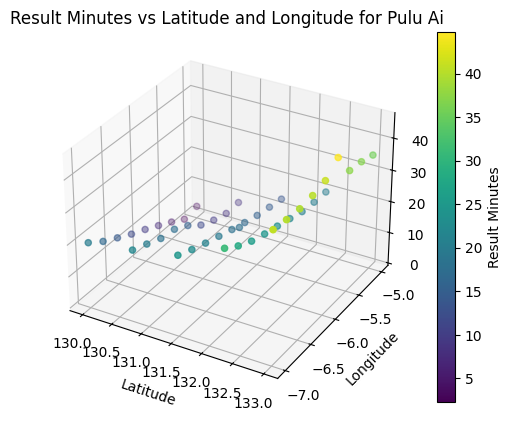

[18.099359441032828, 40.99289074042304, 31.51042416512706, 24.981742049320246, 24.77585535205413, 25.120321556675364, 40.44644766288452, 28.34253442688594, 23.007218766783684, 23.299498206640635, 21.33624640367332, 41.10937303958792, 26.429758773633715, 21.31665057109185, 21.870021340664564, 18.253252284024175, 41.0192742424766, 24.83152132683252, 19.88461303308437, 20.811471772141, 16.019222466535275, 42.08978338605717, 23.66588114808383, 18.31500115234996, 17.760102726668766, 14.104017998106483, 45.16974588687853, 22.355377337521958, 16.964138108261373, 15.4428566510644, 11.618730597497605, 37.473359985509646, 21.05869436750976, 15.68092332142354, 13.19879921829749, 9.4872613931373, 36.987340615531245, 20.56854372970881, 14.62810922890935, 11.67642879435056, 7.760344109680373, 35.19569974844796, 19.9228638119901, 13.670686572383724, 9.453260237031635, 4.601156341431331]


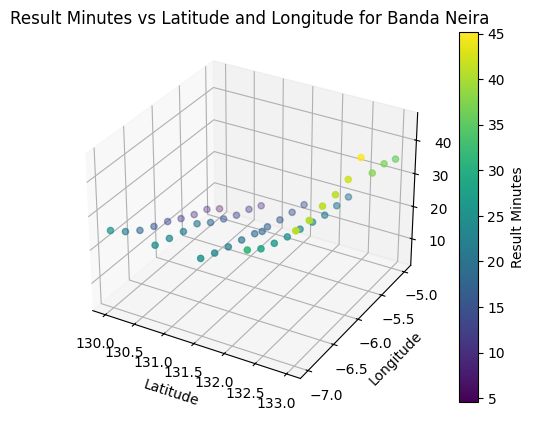

[58.104031525521215, 80.03975878046232, 71.02876433438819, 65.14210632187314, 57.6319913124629, 53.374904270066246, 79.20566472647474, 67.95601974675036, 63.28980959532392, 56.1652839548731, 50.69101189371387, 77.92801203258031, 65.66755166783692, 61.40859796923456, 55.029175568422026, 48.59051922971606, 78.78111818867224, 63.98800019499448, 59.9298226811077, 52.76428958931407, 46.67274774284328, 80.92579437270298, 63.15957256430283, 58.37844928505511, 52.07803375289131, 45.21380077924875, 84.48739217923574, 61.78332262894495, 56.76095842440527, 50.15893165147053, 43.55484558604588, 77.2875879657915, 60.51976559094362, 55.37952897426967, 49.18851394340329, 42.24226707075988, 76.46381219593601, 60.12071363999294, 54.59070397454665, 47.88456551276987, 41.67070874821343, 75.03580055851386, 60.52041822130663, 54.54525683631592, 49.05438382439868, 41.00800467100338]


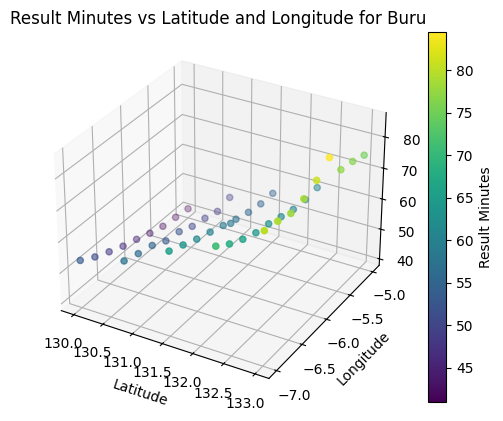

[39.6211922913986, 62.71199831434876, 52.94105996820874, 46.731403691326605, 44.59472527275309, 38.95807237924433, 62.033645985344, 49.61506558912373, 44.7929675933097, 42.837990782887545, 36.95746140376938, 63.6226805888714, 47.64819071847547, 43.162334326684594, 40.82607266535859, 35.15770282926205, 63.1320855521693, 46.43064436446716, 41.49126831436521, 39.35818335770673, 33.34439544080018, 64.77523118563603, 45.12372973043967, 40.12779994909887, 38.72425761640108, 31.603278018958424, 64.60826823860891, 43.85419118925709, 38.562711878609846, 37.08910949438695, 30.0616253819642, 59.656575016601984, 42.76538523130958, 37.21000714210812, 34.934658946765616, 28.955646189925133, 58.21406466770869, 42.06775504067196, 36.205935388947005, 33.46415423279698, 27.14904459892817, 55.720088669721314, 41.69708299962039, 35.252183492484704, 33.108596811340426, 23.656705383536963]


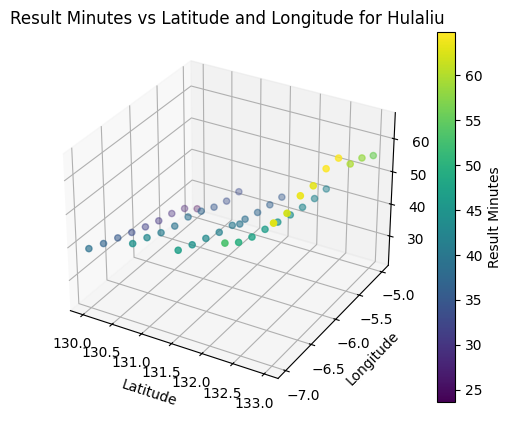

[35.96600524951046, 59.025159391079896, 49.28930456293536, 43.036807784423445, 41.309550311612405, 35.843159416518965, 58.37985061764064, 46.07220672166231, 41.17261669052799, 39.57152130102256, 33.84310617947013, 60.020465778237465, 44.20152287734608, 39.51965681363863, 37.48801333712736, 32.04951626854112, 59.23140669094025, 42.727148335630126, 37.96094397414036, 36.37071209962236, 30.054786092319336, 61.14263589180299, 41.46434935760538, 36.35110701318333, 35.04652081956422, 28.24640720741716, 61.03289082839144, 40.1860269018374, 34.88829867760739, 34.076056744993195, 26.692788428072724, 55.93688197568875, 39.15300530747606, 33.62533451037068, 31.56141140238157, 25.80707394353936, 54.57411127639167, 38.32894020181704, 32.55431070565353, 30.18467488252129, 23.255104906968796, 52.13039144902513, 38.06231067273362, 31.581537858895334, 29.4656665953353, 20.03661967569017]


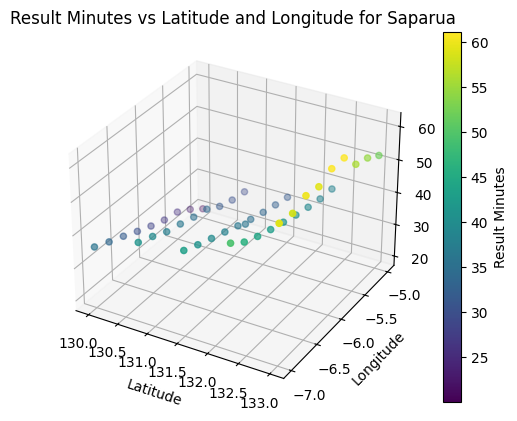

[42.13339174190393, 65.22551228536025, 55.43460672042186, 49.26615750794452, 51.64299423882044, 46.06060881494216, 64.63324663902641, 52.22090354320222, 47.35314322801495, 49.97644454204873, 43.9895627348748, 66.17538404445905, 50.29996545655896, 45.76369663772719, 47.87051820247823, 42.251874196616846, 65.4718634752219, 48.95635821787737, 44.08509851765336, 46.719376685161286, 40.32896314335154, 67.57665876418079, 47.64479687681937, 42.69674396116925, 45.34644415256966, 38.43416403541763, 66.6107923351064, 46.47831783363811, 41.11704829223321, 42.23306808212873, 36.66545429047972, 62.21297056482603, 45.463769555174494, 39.83199958106157, 39.77186278964195, 33.86505452619483, 60.72610950213173, 44.59432396314322, 38.74588096163792, 39.15827682214618, 32.52435514327288, 58.2839764810158, 44.25953710607018, 37.77603258514593, 35.637032733938895, 29.11678735314048]


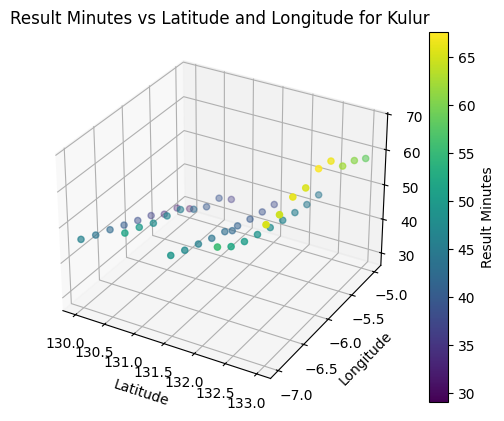

[31.661637816127257, 54.5417518131981, 44.96877690364419, 38.54958807017309, 40.42446656204629, 35.080298089334285, 53.98661718599575, 41.93301928755256, 36.6872627471045, 38.565848286994765, 32.98000748218766, 55.65946310759039, 39.9857709939959, 35.02570413820181, 36.50787168347213, 30.9900203212596, 54.87656121005287, 38.46892484414726, 33.58067206474139, 35.6043451428744, 29.24998206450901, 56.90612042533933, 37.11064888219616, 31.98517912293732, 34.11492417660342, 27.26892269129244, 56.78085938003839, 35.815407906291405, 30.496124098947803, 30.60021396818938, 25.43813127482953, 51.59600822895678, 34.81086629357529, 29.256730294779015, 28.449721975069718, 22.78746528698331, 50.25092245163272, 34.041649691525855, 28.16050437096514, 28.06099737815519, 21.18363457752008, 47.740446771049626, 33.68945297724293, 27.18889643548033, 25.05602213977944, 17.845484147892133]


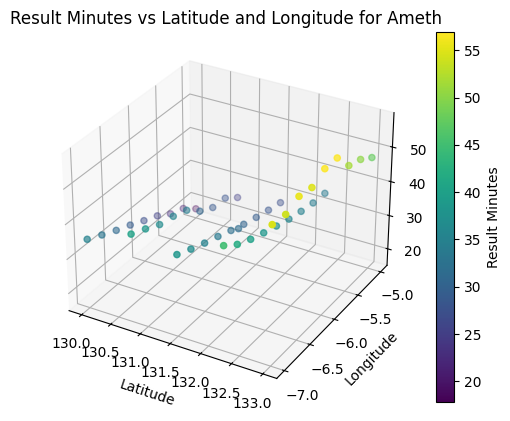

[30.30550248215386, 53.55287571092738, 43.93476015837541, 37.18631802032235, 37.55738477440005, 34.65935329848, 53.28835522461974, 40.70966894197706, 35.1584035120345, 38.07610445144309, 32.559883268733394, 58.72280750679524, 38.27387941155455, 33.526105683460806, 36.0873588266528, 30.95219468395828, 56.36288537169753, 37.09922879467606, 32.09412977483183, 35.52601969792948, 28.98481598687145, 56.92877457717776, 35.57449360773103, 30.48171769887859, 33.43202070614749, 26.950029861933725, 54.49923393819251, 34.411143284240175, 28.95427481428237, 29.89274299974465, 25.046491507698416, 51.1663800664816, 33.715108353599234, 28.075875968097524, 28.435435176177503, 22.722654626859388, 49.36144109926498, 33.13729702375271, 26.77359444695272, 24.95063249670553, 21.075788805244677, 46.26514249605218, 33.00041326121938, 25.944424655875192, 22.64268921249737, 18.039811924091776]


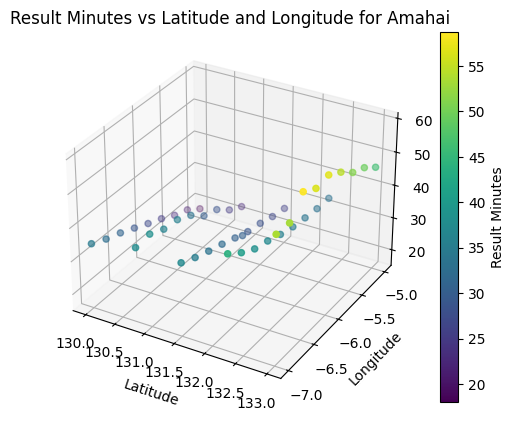

[27.412783825574213, 50.343988657159606, 40.71751328250498, 34.23545646546866, 34.68061597302452, 31.74216641569144, 49.95020749210588, 37.75371857694668, 32.3235146274855, 35.099689043096014, 29.637750658490628, 55.75290269855573, 35.350620434195775, 30.686351951080624, 33.17234942006613, 27.82844967186211, 53.82815010494112, 34.151793112332726, 29.225466025588503, 32.62092585801051, 25.913777563803837, 53.982592255429, 32.76714776629814, 27.50429629715412, 30.507968574876763, 24.032623650984075, 51.532030992433626, 31.46985143641909, 26.012894534673983, 26.991255777392883, 22.12798774004758, 48.21113488422824, 30.774214280177105, 25.03743098808307, 25.342932609210376, 19.664504833961065, 46.732812995681584, 29.98448148555691, 23.82523986986291, 22.214459154431584, 18.003483194758594, 43.40750737040852, 29.72871116718113, 22.870690269782084, 19.738016179782026, 14.89225677909326]


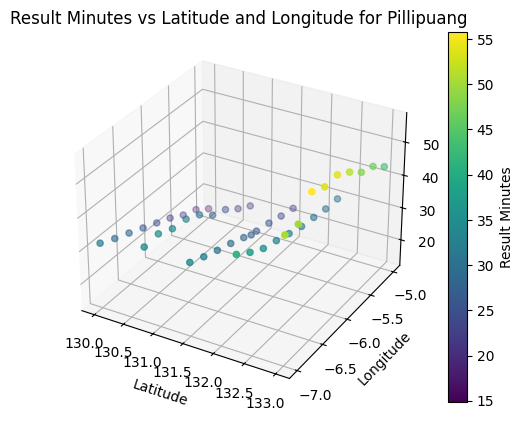

[25.086980913657523, 53.41949771880439, 84.1852809651569, 25.12298020912471, 17.546610442214, 8.726650507412481, 49.96554748629957, 46.3449373124076, 23.503045284328312, 16.506165909317748, 10.824046002926504, 45.770994654884746, 39.35634987143517, 24.19015734976666, 17.41954764927956, 12.757885308819858, 43.75825853729835, 32.93318037082188, 24.01074594704807, 19.065048592769788, 14.385866899984224, 44.50175533307452, 32.232622778107086, 24.50992420595241, 19.68356212725339, 16.629238321541962, 46.01548671053492, 30.803641166319448, 25.2420119602146, 21.19711953952284, 19.58379049943597, 49.8667340867918, 31.264681071688397, 26.13640425743508, 23.21972585191265, 22.525210851904, 51.89425765357217, 32.0029435975093, 27.280503812114823, 25.31201869622885, 24.9841745832286, 55.05860829970388, 33.23521102528303, 28.831760695878486, 28.063054405014174, 27.51008878153567]


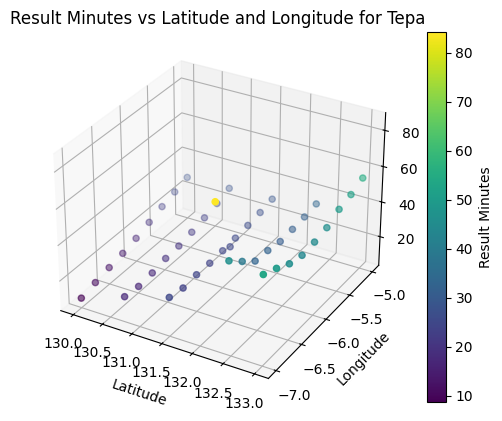

[13.864526164402417, 38.72829894761219, 35.21833527172459, 13.756466333206092, 6.412725240241495, 7.140996538874167, 34.53573604705018, 36.02022538794313, 12.210731795004047, 5.868541287958373, 5.494138797109884, 31.86899255238557, 19.351886824940856, 12.13971003143504, 6.611528919917358, 3.891764652837881, 32.542316999040665, 19.06415075699781, 12.461403623654403, 8.03815737701853, 0.0, 30.391633563916503, 18.925937692284347, 13.384274876133412, 9.683771592481708, 3.562705794324603, 33.57302626008691, 19.5766757109138, 14.181889032301674, 11.621230219320774, 6.936482981153802, 37.10459257550689, 20.104964662983164, 15.41897367058625, 13.714428345832102, 9.001262144716186, 45.10148554322084, 21.3292334836253, 16.80410927750402, 15.81058513813377, 11.523055181347395, 41.91010715407455, 23.2055932807706, 18.17886187682692, 18.68897989652738, 14.352591775210389]


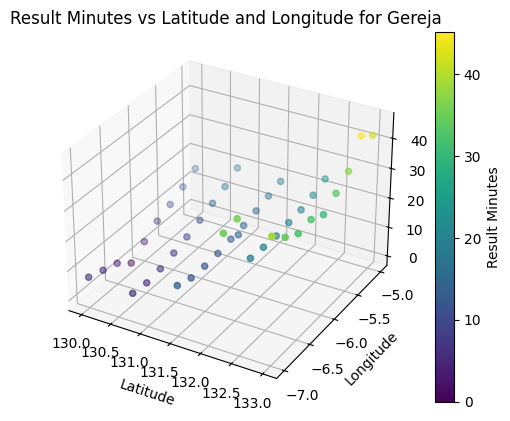

[51.77168598947637, 37.36171469320128, 39.94808574292915, 50.09258112875376, 60.58390955966863, 65.72121606813865, 32.861983892895175, 35.32027207126183, 48.40477926154473, 58.7034453511386, 64.62967425169026, 39.95652659767017, 22.129242403795995, 47.38876448170046, 56.96077389386778, 62.91957039568312, 26.424046376959197, 24.717597365050803, 48.82791158669321, 56.110680103269445, 62.03652371922192, 45.03557753626692, 56.5350608325577, 50.6302747322742, 57.60197146169193, 61.8311743229801, 49.75398554893147, 39.27583306220368, 52.76128938864348, 61.20481127383415, 65.74034577603, 32.22056180103964, 43.5496458941557, 57.384201762073104, 61.65995880752211, 66.8612647028522, 11.384419380662932, 11.384419380662932, 59.83726531567883, 62.72907380441463, 67.3072145457466, -1.0, 33.57452235475196, 64.35204722038536, 64.2337976376568, 68.89543930072887]


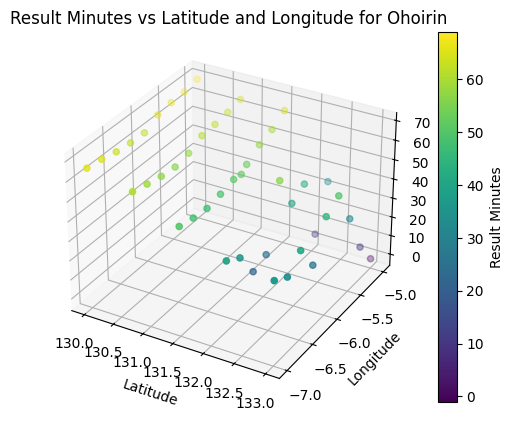

[27.253244640978053, 8.076919203642804, 13.576128934476433, 24.3722507975205, 35.3505892685686, 40.730140340592975, 5.225405522808926, 10.760704938482498, 23.282755141749305, 33.85466257195689, 39.06868574411593, 1.0591732868790242, 12.189732130123458, 22.247796200372232, 31.82349652415969, 37.61399352240824, 40.07661583589996, 19.72841649042887, 23.725112530554707, 31.34325039315245, 36.60251618433834, 26.973721482031426, 34.48782306853205, 26.005517639866053, 32.41108358406003, 36.87736278853877, 11.987183261698554, 42.45927329911365, 30.780779242389336, 33.65571272138626, 38.01535592170636, 6.548584655789642, 43.47217649079865, 34.487134376263015, 34.95099029427779, 39.02299227541411, 3.5072930643536124, 45.59782800276926, 37.107649407469815, 36.39204853862586, 39.84022175006985, 46.25795965744732, 46.66810526262341, 40.27740723834041, 37.84948943775557, 41.57328987250998]


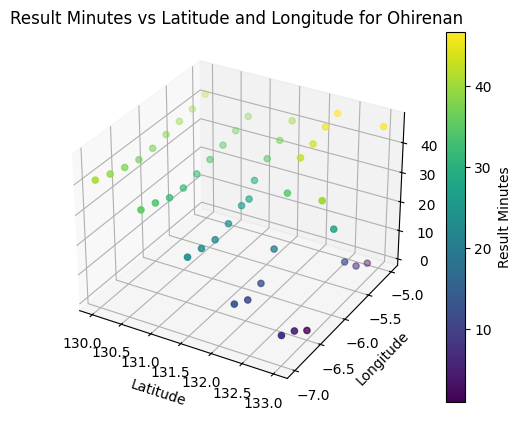

[43.33853952965492, 71.75664837919915, 79.05427448094997, 42.345943527813375, 34.23229122887496, 27.956286890308004, 67.77980339244466, 64.06503408818544, 41.77258257341239, 35.24411122887802, 29.59938057399761, 63.70875613406042, 57.51067521553401, 41.86885222339204, 35.68207958267484, 31.66224076968937, 62.10378747454027, 49.01262470183988, 42.07476911253374, 37.07119592268841, 37.8228000637405, 61.20028026728805, 49.10517260307255, 42.63534625930544, 38.795193552387765, 37.20650094831836, 64.14691052519646, 48.79183358875275, 43.43791103276322, 41.01011274446767, 38.13708341743931, 65.6797125290299, 49.433289199135, 44.61520842943057, 47.780423953759424, 38.98138683804677, 72.31136007350322, 50.60395620823964, 46.01593996509182, 47.94704027926043, 41.38139407210439, 69.15731185454156, 51.97501501910858, 47.53224067701727, 49.6657642503225, 42.38810582787755]


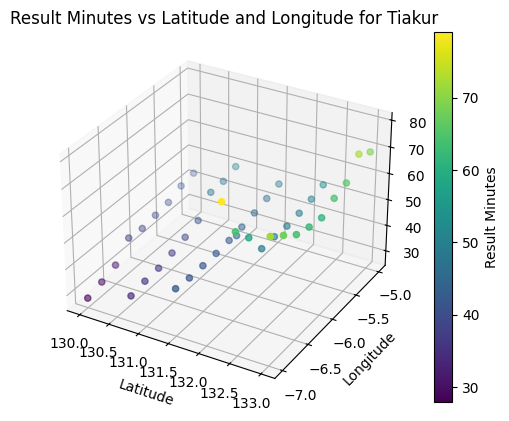

[6.134779145075725, 25.174820523764183, 14.887913255640486, 8.940613553818203, 5.4334425901527394, 12.695346596486267, 22.457646591316085, 21.90444556929409, 15.396477995749876, 4.203154507270275, 11.305536025942194, 20.652185617266426, 14.39101575818736, 48.32370218570237, 4.999143853312303, 11.46348128591644, 21.249307381270327, 10.173089920166998, 21.472424350488478, 6.19871565586657, 11.89176460053694, 22.257325642745563, 10.603642258658592, 7.449693554321342, 7.493945507764658, 13.068502444093674, 26.235864055240143, 12.954730083524566, 6.935592040235712, 9.247285814308508, 13.915848654040214, 41.92223613013739, 14.3538750230862, 9.02581325597813, 10.40971127443674, 15.447266220002126, 35.748911659923465, 15.739447192000636, 10.90268067430397, 12.093511002850482, 16.974150575993917, 42.61371523438296, 19.18733925628876, 12.561255462959371, 13.589840338498671, 18.32388713675897]


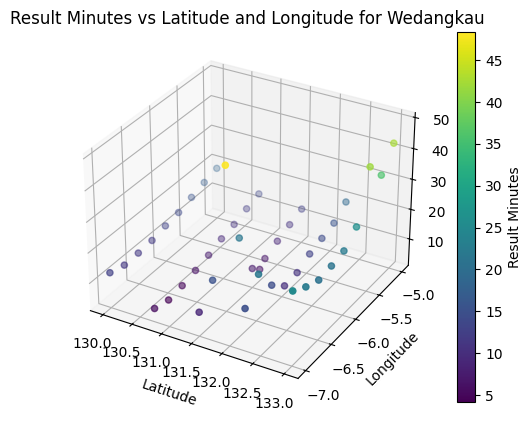

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]


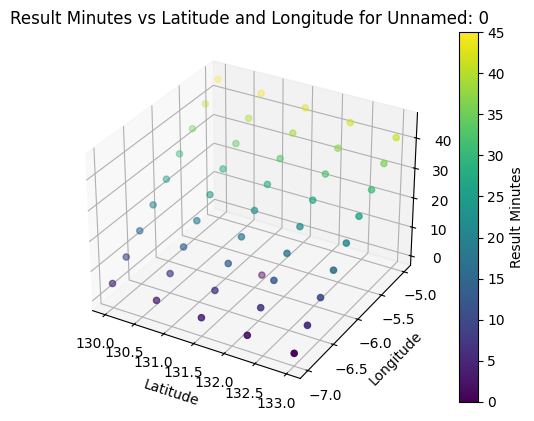

[20.87242, 20.87242, 20.87242, 24.901735, 21.76104833333333, 21.49777, 21.49777, 21.49777, 23.591166666666663, 23.61442, 18.681975, 18.681975, 18.681975, 22.581885, 20.91759833333333, 16.091979833333333, 16.091979833333333, 25.79517333333333, 22.46162333333333, 18.48433333333333, 15.821409166666664, 15.821409166666664, 24.38320666666667, 20.98046833333333, 14.531516666666668, 0.1654218566666666, 0.1654218566666666, 23.26751, 19.823371666666667, 11.665835333333332, 0.1654218566666666, 0.1654218566666666, 22.329986666666667, 19.145515, 20.387431666666664, 0.1654218566666666, 0.1654218566666666, 21.845425, 15.316103, 20.0697, 0.1654218566666666, 0.1654218566666666, 22.142375, 15.401942333333333, 19.897175, 0.7201792166666666]


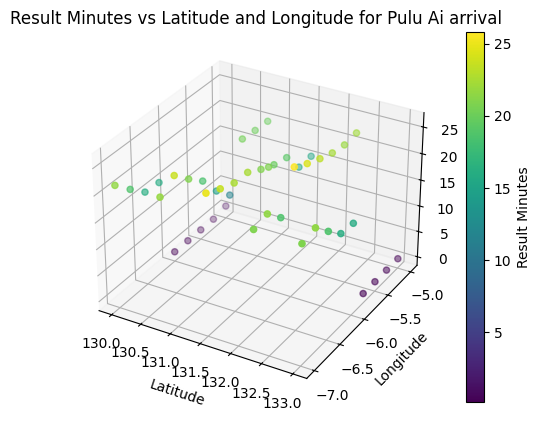

[44.47568, 44.47568, 44.47568, 48.9979, 44.861045, 88.93693333333334, 88.93693333333334, 88.93693333333334, 47.481676666666665, 43.74861333333333, 57.939193333333336, 57.939193333333336, 57.939193333333336, 46.09359333333334, 43.40853833333333, 56.381585, 56.381585, 50.349273333333336, 45.487545, 42.69131, 55.080275, 55.080275, 49.02294, 44.46563333333334, 40.84068166666667, 79.46384166666667, 79.46384166666667, 48.224336666666666, 43.53192, 38.22817166666667, 78.99383833333333, 78.99383833333333, 47.938025, 42.79089166666667, 36.66028166666667, 78.56319666666667, 78.56319666666667, 47.846601666666665, 65.12716666666667, 82.26622333333333, 77.92447166666668, 77.92447166666668, 48.10636833333333, 65.25835000000001, 82.11303833333334, 19.882853333333333]


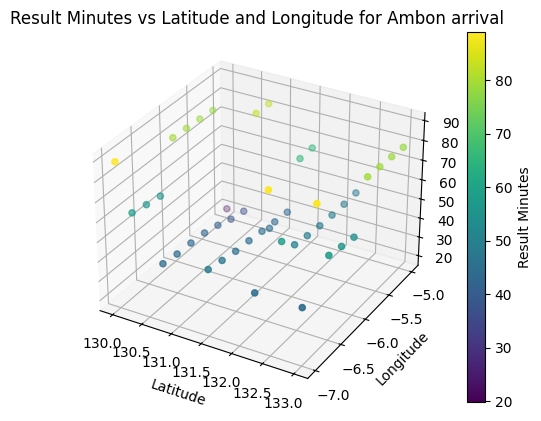

[22.52567, 22.52567, 22.52567, 29.522683333333337, 25.70874333333333, 25.219328333333333, 25.219328333333333, 25.219328333333333, 27.71637666666667, 24.923251666666665, 22.10211, 22.10211, 22.10211, 26.04441166666667, 23.713406666666668, 17.955658333333336, 17.955658333333336, 30.00145333333333, 24.38929166666667, 20.633945, 15.751386, 15.751386, 28.406206666666662, 22.703746666666667, 17.004006666666665, 0.1654218566666666, 0.1654218566666666, 27.03723, 21.196791666666662, 26.303705, 0.1654218566666666, 0.1654218566666666, 26.207318333333333, 20.465151666666667, 23.695685, 0.1654218566666666, 0.1654218566666666, 25.658136666666667, 19.32878333333333, 23.237836666666663, 22.585381666666667, 22.585381666666667, 25.05045833333333, 13.694888, 23.059915, 23.20632833333333]


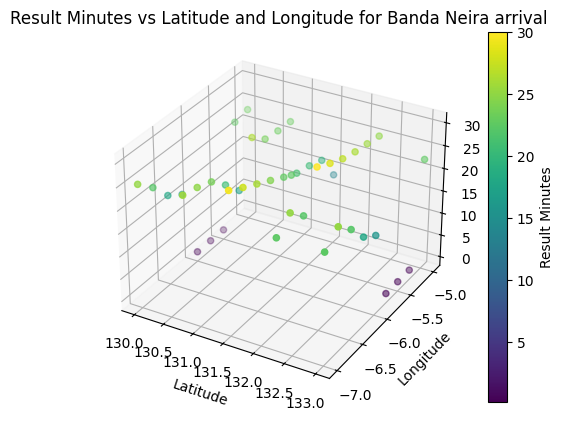

[59.36029333333333, 59.36029333333333, 59.36029333333333, 65.67796666666666, 58.853805, 56.49112333333333, 56.49112333333333, 56.49112333333333, 63.93479833333333, 57.69386833333333, 52.294215, 52.294215, 52.294215, 62.20079666666666, 57.48471666666667, 49.08747166666667, 49.08747166666667, 67.35806166666667, 60.624723333333336, 56.235771666666665, 47.05912666666666, 47.05912666666666, 65.96667, 59.29123666666667, 54.62869333333333, 78.30027166666667, 78.30027166666667, 77.88309166666666, 58.14343833333333, 52.846485, 76.75292333333333, 76.75292333333333, 64.73554, 57.30098, 51.63971, 76.19839333333333, 76.19839333333333, 64.63337333333332, 56.70880666666667, 83.419335, 77.48274166666667, 77.48274166666667, 64.69956833333333, 56.56044666666666, 83.59476166666667, 35.94667666666667]


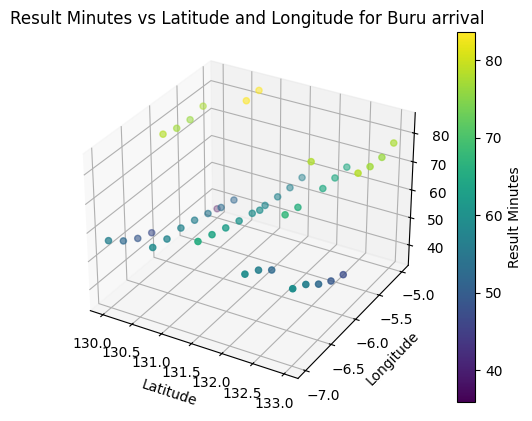

[44.94958333333333, 44.94958333333333, 44.94958333333333, 51.14684166666667, 46.25601833333334, 58.97403166666666, 58.97403166666666, 58.97403166666666, 49.46356333333333, 45.321475, 59.953700000000005, 59.953700000000005, 59.953700000000005, 61.139925, 44.38901333333333, 57.96534, 57.96534, 51.991978333333336, 46.440691666666666, 55.60545833333333, 56.57781, 56.57781, 50.64944333333334, 45.00416833333334, 55.03277666666667, 55.64876833333334, 55.64876833333334, 49.683845, 43.973565, 55.0071, 80.87922833333333, 80.87922833333333, 49.203625, 43.57189666666667, 54.78639166666667, 81.22429666666667, 81.22429666666667, 49.02064166666666, 42.95270166666667, 54.33909833333333, 81.05969166666667, 81.05969166666667, 49.31812, 42.60057, 53.874541666666666, 32.04103833333333]


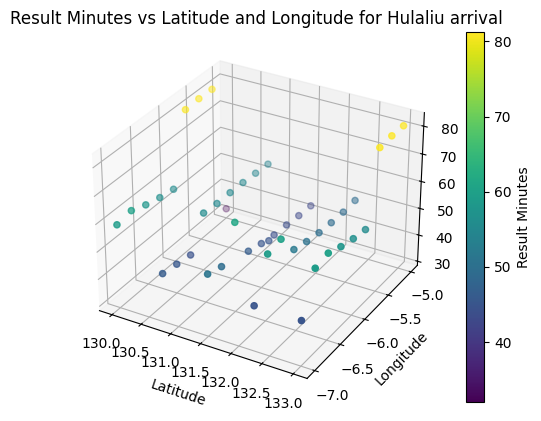

[42.08460166666667, 42.08460166666667, 42.08460166666667, 47.22057333333333, 42.42115666666667, 41.71133833333333, 41.71133833333333, 41.71133833333333, 45.45668, 42.18112166666666, 55.70923333333334, 55.70923333333334, 55.70923333333334, 43.77792333333333, 40.80108666666667, 54.14600166666666, 54.14600166666666, 48.11951333333333, 42.24033, 39.15146166666667, 51.40104166666666, 51.40104166666666, 46.507775, 42.171455, 35.94286666666667, 50.924605, 50.924605, 45.48303, 40.94128333333333, 51.83350833333333, 50.616415, 50.616415, 44.90595833333334, 39.92539833333333, 51.33258, 50.2663, 50.2663, 44.696085, 39.457033333333335, 51.34332333333334, 49.271121666666666, 49.271121666666666, 44.86964666666667, 38.738915, 50.90043, 49.25303333333333]


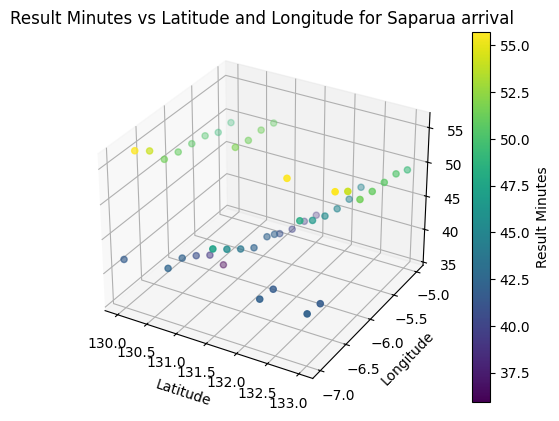

[54.17447666666667, 54.17447666666667, 54.17447666666667, 61.11612333333333, 55.686906666666665, 52.33309, 52.33309, 52.33309, 59.082346666666666, 54.36519333333333, 49.40152333333333, 49.40152333333333, 49.40152333333333, 57.28952, 53.47156, 46.0921, 46.0921, 62.08531833333333, 55.686755, 51.128456666666665, 43.13733666666667, 43.13733666666667, 60.41396, 54.23997, 48.84198166666667, 41.56772166666666, 41.56772166666666, 59.35648666666667, 53.08636333333333, 45.071235, 37.02038, 37.02038, 58.85992, 51.93660333333333, 43.670405, 31.89230333333333, 31.89230333333333, 58.88161333333333, 51.30129333333333, 42.88374833333333, 29.813938333333333, 29.813938333333333, 59.35699666666667, 51.50871, 37.09082166666667, 26.777815]


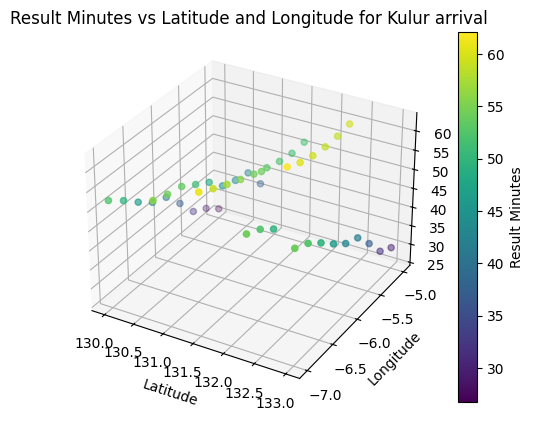

[35.42825333333334, 35.42825333333334, 35.42825333333334, 51.58309333333333, 43.907718333333335, 36.325230000000005, 36.325230000000005, 36.325230000000005, 38.89154833333334, 39.35854500000001, 33.85544, 33.85544, 33.85544, 37.455535000000005, 35.882535, 30.04364333333333, 30.04364333333333, 52.91297333333333, 36.05814833333333, 34.39408, 27.493593333333333, 27.493593333333333, 51.70505166666667, 35.515, 33.10874666666667, 25.526125, 25.526125, 38.25002, 34.66122666666667, 29.730755, 24.49686833333333, 24.49686833333333, 38.270880000000005, 33.96817, 28.13571166666667, 12.728607333333334, 12.728607333333334, 38.10414, 32.92349333333333, 24.16462, 12.125556333333332, 12.125556333333332, 37.378205, 31.376368333333332, 22.65041666666667, 11.549867833333334]


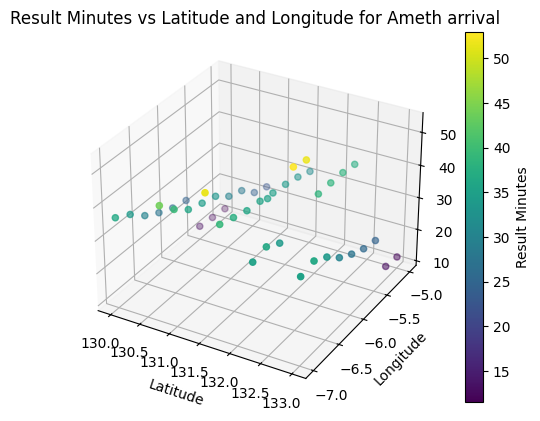

[42.86009, 42.86009, 42.86009, 87.56049333333334, 47.155478333333335, 43.725805, 43.725805, 43.725805, 84.99764833333333, 45.26222333333333, 40.02304166666667, 40.02304166666667, 40.02304166666667, 45.17809666666667, 43.009881666666665, 36.66438, 36.66438, 56.365390000000005, 44.44823, 40.49843166666667, 33.726263333333335, 33.726263333333335, 54.742635, 43.108518333333336, 37.12285, 62.452245, 62.452245, 77.72152166666666, 70.91291500000001, 33.51347, 61.82624166666667, 61.82624166666667, 76.58380333333334, 70.24359, 29.74150333333333, 60.151135, 60.151135, 75.60923666666666, 68.051795, 25.969685, 17.624826666666667, 17.624826666666667, 75.62720666666668, 67.90277833333333, 24.035161666666667, 16.893401666666666]


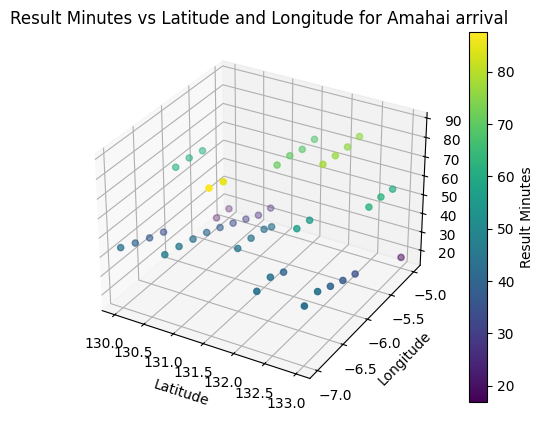

[37.14078833333333, 37.14078833333333, 37.14078833333333, 51.98703166666667, 41.618625, 39.34143, 39.34143, 39.34143, 41.352815, 40.24733166666667, 35.17514166666667, 35.17514166666667, 35.17514166666667, 39.83048166666666, 37.940446666666666, 32.06921333333334, 32.06921333333334, 52.24511666666667, 38.664541666666665, 35.54166, 29.45980833333333, 29.45980833333333, 50.95643166666667, 37.50222333333333, 32.21431833333333, 25.870845, 25.870845, 41.002125, 36.34702, 29.33739166666667, 24.52379833333333, 24.52379833333333, 40.26357333333333, 34.79225833333333, 25.45228333333333, 17.11273333333333, 17.11273333333333, 40.183, 33.62369666666667, 21.411256666666667, 13.1973245, 13.1973245, 40.168011666666665, 32.8898, 19.44461, 11.4152105]


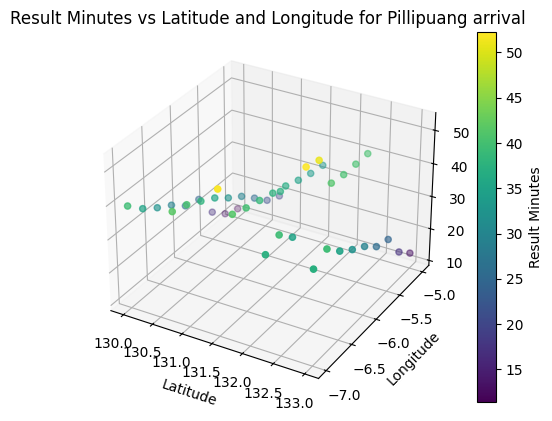

[82.94172333333333, 82.94172333333333, 82.94172333333333, 23.66304333333333, 25.854155, 34.63939166666667, 34.63939166666667, 34.63939166666667, 22.77261333333333, 23.40436, 8.9224635, 8.9224635, 8.9224635, 23.104221666666668, 14.550582833333332, 9.935048833333331, 9.935048833333331, 42.03347333333333, 24.373138333333333, 35.250725, 11.102919333333334, 11.102919333333334, 87.81672499999999, 83.099165, 34.908363333333334, 12.9012115, 12.9012115, 86.94178833333334, 81.4475, 34.24627833333333, 14.010414166666669, 14.010414166666669, 47.733375, 81.12899, 35.31321833333333, 15.674614666666669, 15.674614666666669, 47.291895, 81.50649, 36.170025, 33.24531666666667, 33.24531666666667, 48.170995, 35.405035, 37.106985, 75.54311833333333]


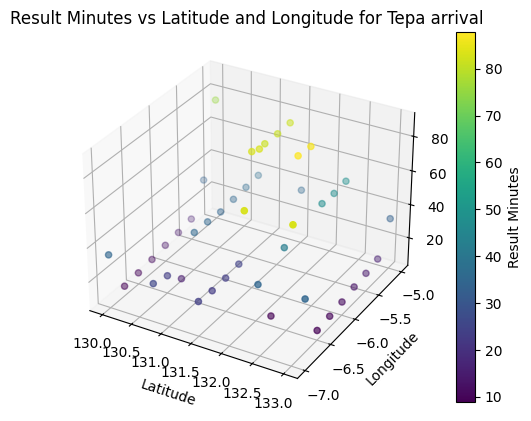

[0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666, 0.1654218566666666]


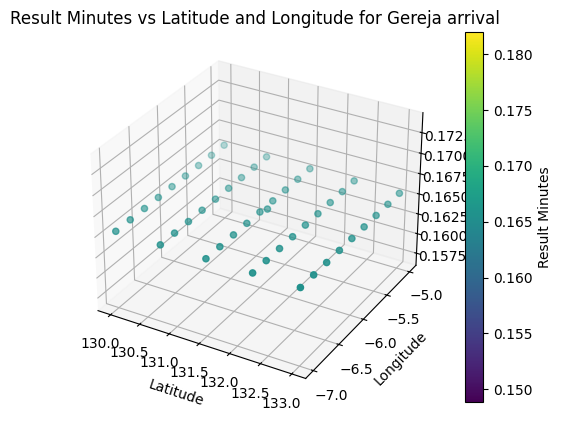

[37.20002833333333, 37.20002833333333, 37.20002833333333, 39.745021666666666, 45.135731666666665, 50.776465, 50.776465, 50.776465, 66.55222, 43.08068166666667, 50.30651666666667, 50.30651666666667, 50.30651666666667, 19.399435, 43.73716, 50.84371833333333, 50.84371833333333, 48.04949833333333, 45.735255, 44.46389666666666, 52.09056666666667, 52.09056666666667, 44.493485, 37.416055, 45.485225, 53.28938333333333, 53.28938333333333, 68.54444, 38.829971666666665, 46.208145, 54.04774833333333, 54.04774833333333, 65.39258166666667, 47.326095, 46.44535, 53.83235666666667, 53.83235666666667, 63.73399, 40.05491, 46.23522333333334, 53.06356, 53.06356, 61.26353666666667, 38.84124666666666, 45.87336333333334, 52.10293]


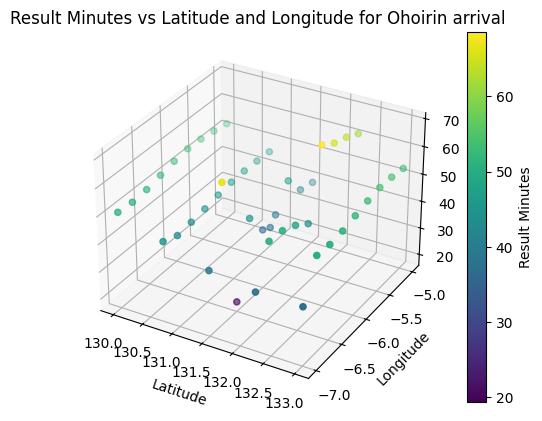

[21.80406, 21.80406, 21.80406, 9.9671955, 30.022626666666667, 33.19592333333333, 33.19592333333333, 33.19592333333333, 11.188675333333332, 26.409811666666663, 34.00626333333334, 34.00626333333334, 34.00626333333334, 16.270728833333333, 29.795185, 35.54387166666667, 35.54387166666667, 3.278483833333333, 29.300055, 31.226116666666663, 37.02306, 37.02306, 1.1295135166666666, 21.879810000000003, 32.15504833333333, 38.012425, 38.012425, 0.2300538, 23.47507, 32.775265000000005, 38.539415, 38.539415, 23.067741666666667, 24.569543333333336, 32.872285, 38.113855, 38.113855, 8.506564000000001, 24.66664833333333, 32.50595166666667, 37.40926666666667, 37.40926666666667, 0.1654218566666666, 23.523841666666662, 31.400896666666664, 55.259935000000006]


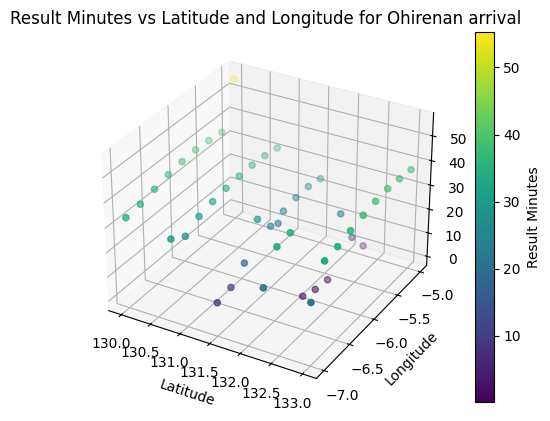

[55.57998833333333, 55.57998833333333, 55.57998833333333, 74.18215166666667, 76.35751166666667, 87.33184, 87.33184, 87.33184, 74.64122333333333, 73.53981999999999, 87.84036666666665, 87.84036666666665, 87.84036666666665, 75.43199166666666, 41.625345, 89.15711, 89.15711, 67.69737, 76.85468, 86.61074666666667, 67.31931666666667, 67.31931666666667, 66.38676, 54.907735, 87.27459833333334, 68.52322666666667, 68.52322666666667, 63.115658333333336, 55.24599833333333, 45.162835, 68.87216833333333, 68.87216833333333, 62.92062, 56.083765, 47.81399333333333, 68.51152499999999, 68.51152499999999, 63.44855666666667, 56.59570166666666, 49.54365333333333, 69.24619, 69.24619, 65.001165, 57.95532166666667, 52.09116166666667, 70.88316499999999]


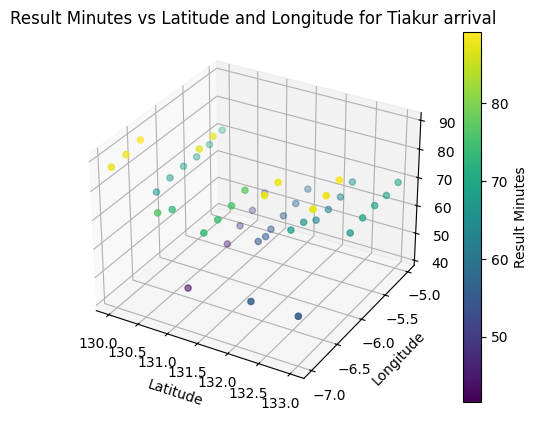

[18.85832, 18.85832, 18.85832, 15.643749666666668, 19.445175, 20.135203333333333, 20.135203333333333, 20.135203333333333, 16.92409, 20.102645, 11.076839, 11.076839, 11.076839, 18.08551, 6.837808999999999, 12.321295999999998, 12.321295999999998, 14.474752333333331, 18.385341666666665, 7.963892, 13.214328, 13.214328, 15.1041995, 19.19792, 9.462205333333332, 13.703713333333331, 13.703713333333331, 16.126716833333333, 19.220143333333333, 9.968638, 13.935014166666669, 13.935014166666669, 18.47968, 20.15274833333333, 21.077051666666662, 13.881114166666666, 13.881114166666666, 22.89551, 20.19058, 20.543815, 13.423532, 13.423532, 24.969676666666665, 21.229385, 20.522156666666667, 12.756422166666663]


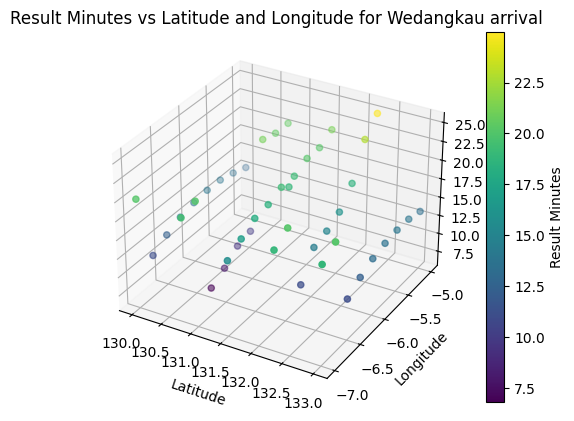

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

output = pd.read_csv('model_output_new_locs.csv')
params = pd.read_csv('model_params_new_locs.csv')
results = pd.read_csv("time_model_results.csv")

y_lst = params['latitude'].tolist()
x_lst = params['longitude'].tolist()
models = [results, output]
for model in models:
    for col in model:
        z_lst = model[col].tolist()
        print(z_lst)
        # Plotting the results
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        
        # Create the scatter plot
        scat = ax.scatter(x_lst, y_lst, z_lst, c=z_lst, cmap='viridis')
        # Set the title
        ax.set_title(f'Result Minutes vs Latitude and Longitude for {col}')
        # Label the axes
        ax.set_xlabel('Latitude')
        ax.set_ylabel('Longitude')
        ax.set_zlabel('Arrival Time in Minutes')
        
        # Optional: Add a color bar to map colors to z-values
        fig.colorbar(scat, ax=ax, label='Result Minutes')
        
        # Show the plot
        plt.show()

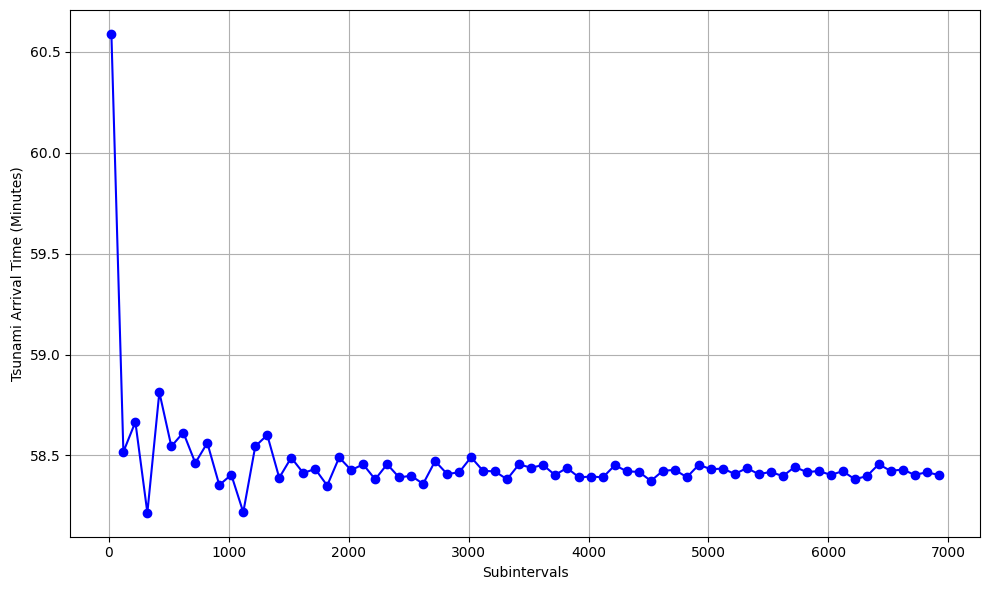

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Define observation location and earthquake center
buru = (127.113, -3.3815)
saparua= (128.657, -3.576)
eq_center = (131.75, -5.52)
width = 103587.2508

# Store results
subintervals_list = list(range(20, 7000, 100))
refined_times = []
# Create an instance of TimeModel
time_model_instance = TimeModel(file_path)

# Compute path and initial total time using Dijkstra's algorithm
path, total_time = time_model_instance.dijkstras_algorithm(eq_center, buru, width)
control_points = np.array(path)
runner = TimeModelSimpsons(control_points)

# Loop over subintervals
for subintervals in subintervals_list:
    # Run Simpson's method
    refined_time = runner.simpson(0.0, 1.0, int(subintervals))
    refined_time = (refined_time * 111120) / 60  # Convert to desired units
    refined_times.append(refined_time)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(subintervals_list, refined_times, marker='o', linestyle='-', color='b')
plt.xlabel('Subintervals')
plt.ylabel('Tsunami Arrival Time (Minutes)')
plt.grid(True)
plt.tight_layout()
plt.show()


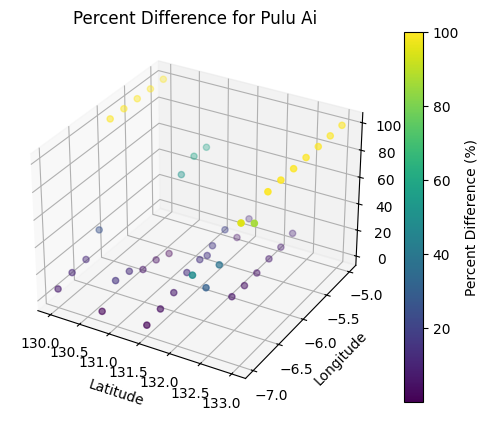

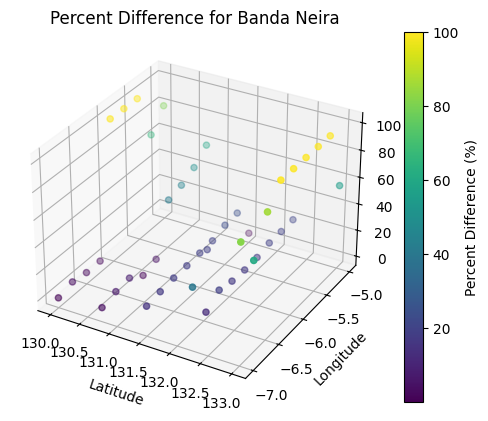

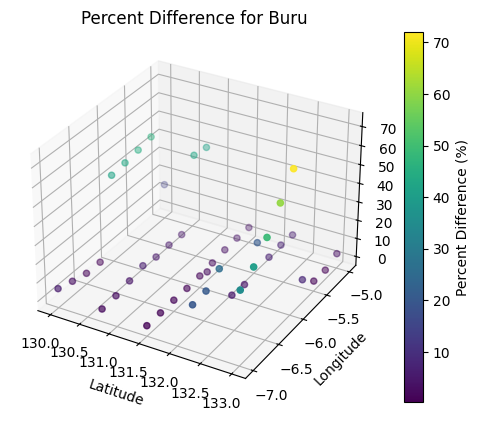

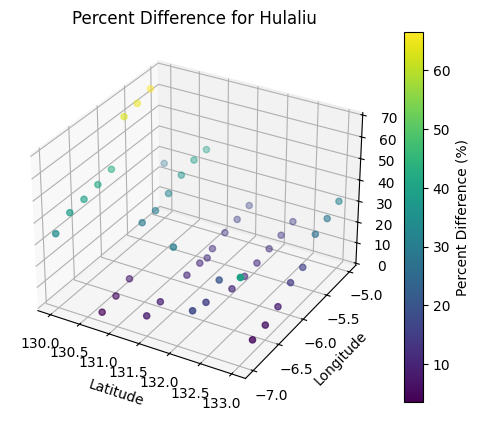

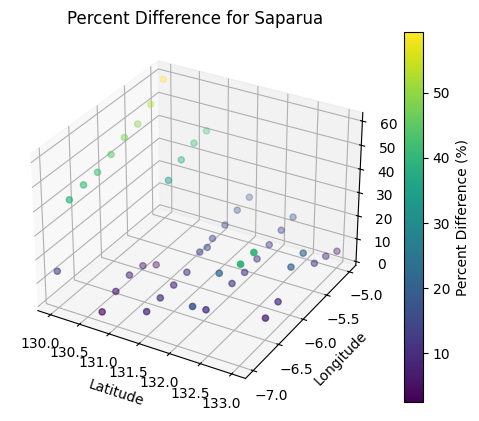

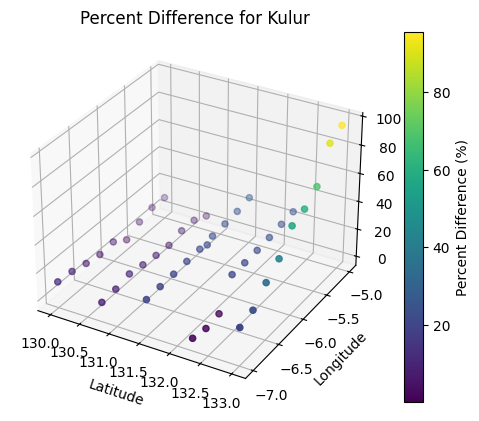

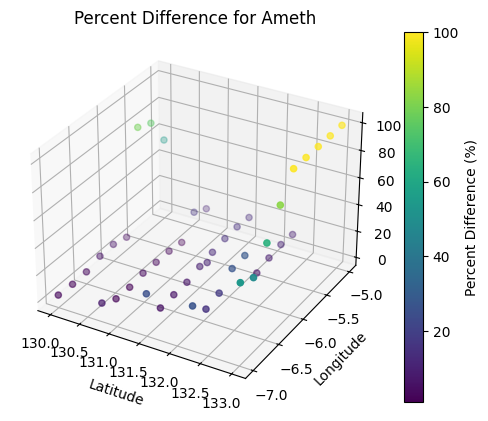

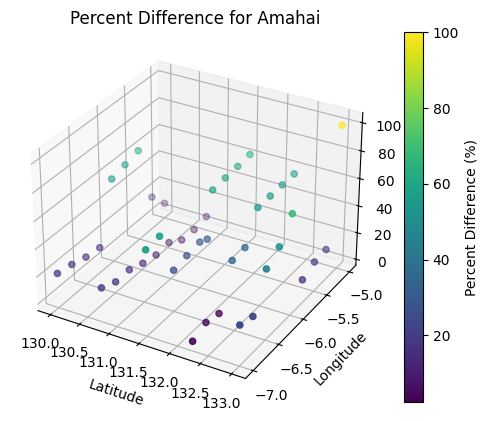

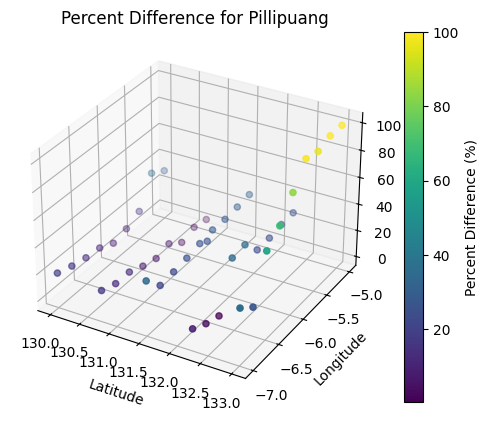

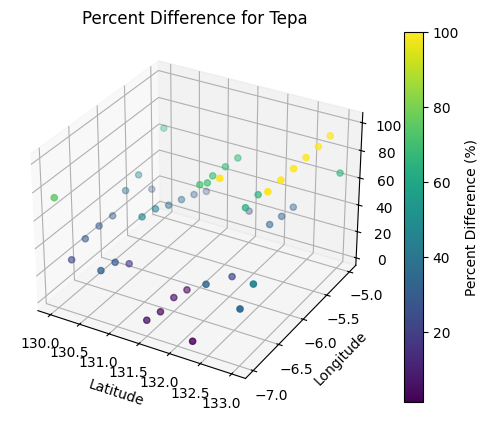

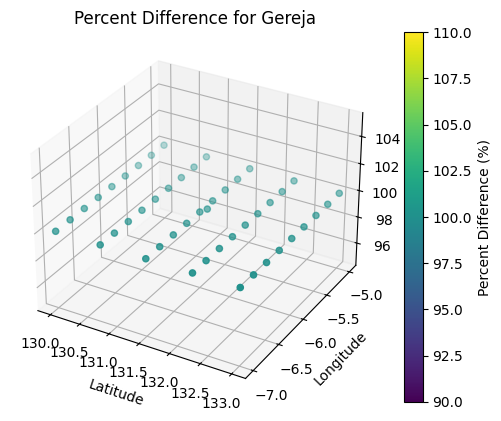

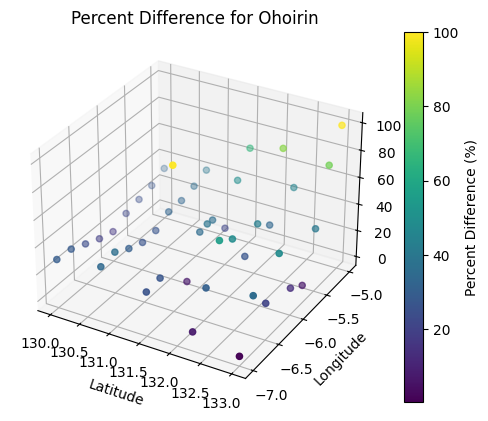

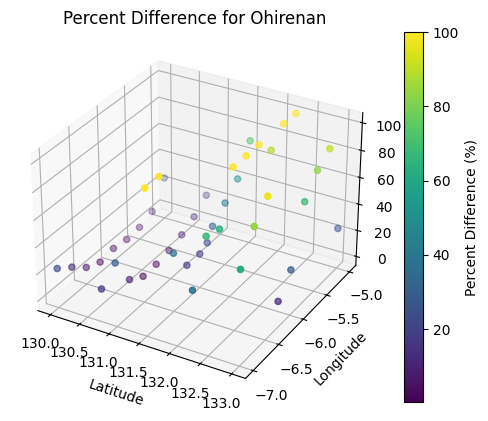

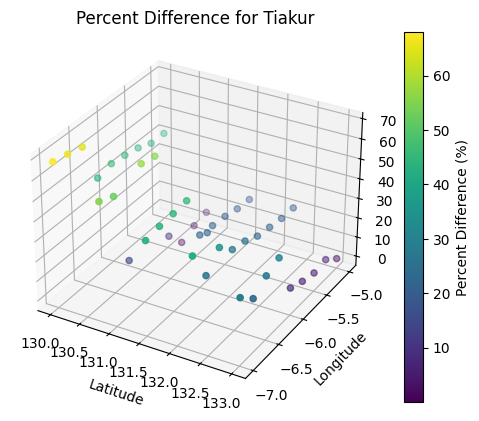

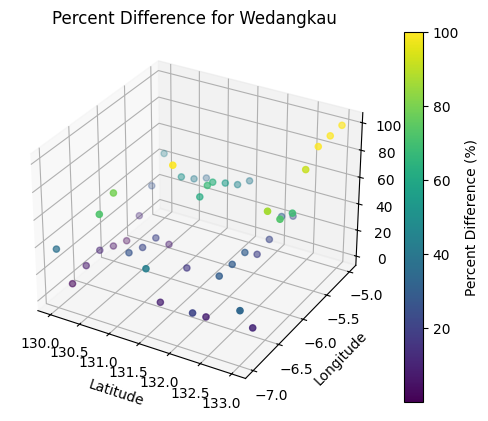

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Read the data
output = pd.read_csv('model_output_new_locs.csv')
params = pd.read_csv('model_params_new_locs.csv')


# Get the latitude and longitude lists
y_lst = params['latitude'].tolist()
x_lst = params['longitude'].tolist()

# Lists to store percent differences for each column
percent_differences = {}

# Calculate the percent difference between corresponding columns in 'results' and 'output'
for col in results.columns:
    col_name = f'{col} arrival'
    z_output = output[col_name].tolist()
    z_results = results[col].tolist()
    
    # Ensure both columns have the same length
    if len(z_output) == len(z_results):
        # Calculate percent difference
        percent_diff = [(abs(r - o) / o) * 100 if (abs(r - o) / o) * 100 < 100 else 100 for r, o in zip(z_results, z_output)]

        percent_differences[col] = percent_diff
        
        # Plot the percent differences
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        
        # Create the scatter plot for percent differences
        scat = ax.scatter(x_lst, y_lst, percent_diff, c=percent_diff, cmap='viridis')
        
        # Set the title
        ax.set_title(f'Percent Difference for {col}')
        
        # Label the axes
        ax.set_xlabel('Latitude')
        ax.set_ylabel('Longitude')
        ax.set_zlabel('Percent Difference (%)')
        
        # Optional: Add a color bar to map colors to percent differences
        fig.colorbar(scat, ax=ax, label='Percent Difference (%)')
        
        # Show the plot
        plt.show()
    else:
        print(f"Column {col} has mismatched lengths between results and output.")


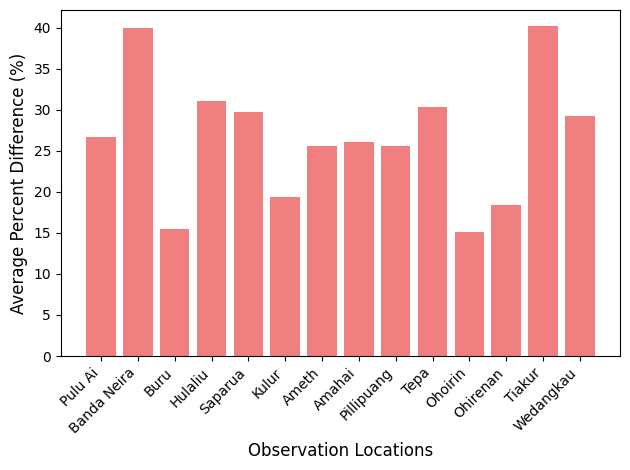

Total MAE across all locations: 16.480381134409996
6
Overall Average Percent Difference across all locations: 26.60%
{'Pulu Ai': 26.61716274693414, 'Banda Neira': 39.9337275299302, 'Buru': 15.442320322957354, 'Hulaliu': 30.99994561575197, 'Saparua': 29.738726845018498, 'Kulur': 19.32576591795952, 'Ameth': 25.53431488967281, 'Amahai': 26.026451918153768, 'Pillipuang': 25.590627114556273, 'Tepa': 30.28020205007443, 'Ohoirin': 15.138560983287412, 'Ohirenan': 18.438560822900577, 'Tiakur': 40.12990237833673, 'Wedangkau': 29.17838585236398}


In [2]:
# Dictionaries to store MAE and average percent difference for each location
mae_per_location = {}
percent_diff_per_location = {}

# output = pd.read_csv('model_output_new_locs.csv')
# params = pd.read_csv('model_params_new_locs.csv')
output = pd.read_csv('geo_results.csv')
params = pd.read_csv('geo_params.csv')
results = pd.read_csv("time_model_results.csv")

columns_to_process = [col for col in results.columns if col != 'Gereja']

# Calculate MAE and percent difference between corresponding columns in 'results' and 'output'
for col in columns_to_process:
    if col == 'Gereja':  # Skip 'Gereja'
        continue

    
    col_name = f'{col} arrival'  # Assuming the format in output
    z_output = output[col_name].tolist()  # Trusted model output
    z_results = results[col].tolist()  # Test model output
    
    # Ensure both columns have the same length
    if len(z_output) == len(z_results):
        # Calculate MAE for this location (column)
        mae = np.mean(abs(np.array(z_results) - np.array(z_output)))
        mae_per_location[col] = mae  # Store MAE for each location
        
        # Calculate percent difference for each value
        # percent_diff = [(abs(r - o) / o) * 100 if (abs(r - o) / o) * 100 < 100 else 0 for r, o in zip(z_results, z_output)]
        count_else_triggered = 0
        percent_diff = []

        for r, o in zip(z_results, z_output):
            error = (abs(r - o) / o) * 100
            if error < 100:
                percent_diff.append(error)
            else:
                count_else_triggered += 1
        avg_percent_diff = np.mean(percent_diff)  # Average percent difference for this location
        percent_diff_per_location[col] = avg_percent_diff  # Store in the dictionary

# --- Plotting the MAE Bar Chart ---
locations = list(mae_per_location.keys())
mae_values = list(mae_per_location.values())

# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)  # First plot (left)
# plt.bar(locations, mae_values, color='skyblue')
# plt.title('Mean Error for Each Observation Location', fontsize=14)
# plt.xlabel('Observation Locations', fontsize=12)
# plt.ylabel('Mean Error', fontsize=12)
# plt.xticks(rotation=45, ha='right')

# --- Plotting the Average Percent Difference Bar Chart ---
percent_diff_values = list(percent_diff_per_location.values())

plt.subplot(1, 1, 1)  # Second plot (right)
plt.bar(locations, percent_diff_values, color='lightcoral')
# plt.title('Average Percent Difference for Each Observation Location', fontsize=14)
plt.xlabel('Observation Locations', fontsize=12)
plt.ylabel('Average Percent Difference (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Adjust layout and display both plots
plt.tight_layout()
plt.show()

# Calculate and print the total MAE across all locations
total_mae = np.mean(mae_values)
print(f'Total MAE across all locations: {total_mae}')
print(count_else_triggered)

# Calculate and print the overall average percent difference across all locations
overall_avg_percent_diff = np.mean(percent_diff_values)
print(f'Overall Average Percent Difference across all locations: {overall_avg_percent_diff:.2f}%')
print(percent_diff_per_location)

In [ ]:
# Define locations with coordinates
locations = {
    "Pulu Ai": (129.775, -4.5175),
    "Banda Neira": (129.8965, -4.5248),
    "Buru": (127.113, -3.3815),
    "Hulaliu": (128.557, -3.543),
    "Saparua": (128.657, -3.576),
    "Kulur": (128.562, -3.501),
    "Ameth": (128.807, -3.6455),
    "Amahai": (128.921, -3.338),
    "Pillipuang": (128.921, -3.4),
    "Tiakur": (127.7806026, -8.147154),
    "Tepa": (129.5703889, -7.8639903),
    "Ohoirin": (132.6465723, -5.8371713),
    "Ohirenan": (132.9668690, -5.7912256),
    "Wedangkau": (131.5561104, -6.7019795),
    "Gereja": (129.5085225, -6.7096992)
}
earthquake_center = (131.75, -5.52)

# Function to calculate Euclidean distance
def euclidean_distance(coord1, coord2):
    return np.sqrt((coord1[0] - coord2[0])**2 + (coord1[1] - coord2[1])**2)

# Calculate distances for each location
distances = {}
for location, coord in locations.items():
    distances[location] = euclidean_distance(earthquake_center, coord)

# Sort distances in ascending order
sorted_distances = sorted(distances.items(), key=lambda x: x[1])

# Print sorted distances
for location, distance in sorted_distances:
    print(f"{location}: {distance:.2f}")

Ohoirin: 0.95
Wedangkau: 1.20
Ohirenan: 1.25
Banda Neira: 2.10
Pulu Ai: 2.21
Gereja: 2.54
Tepa: 3.20
Ameth: 3.49
Pillipuang: 3.54
Amahai: 3.57
Saparua: 3.65
Hulaliu: 3.76
Kulur: 3.77
Tiakur: 4.76
Buru: 5.11
